# Mini-Lab: Bias, Variance, and Overfitting (Regression)

**Topic dataset:** Fertilizer rate → Crop yield

This dataset has an **inverted-U** pattern: adding fertilizer helps up to a point, but **too much fertilizer hurts yield**.
You'll fit models of different complexity and compare **bias, variance, and overfitting** using a train/test split.

## What you will do

1. Plot the data (scatter).
2. Fit a **linear regression** model (straight line).
3. Fit **polynomial regression** models (curves) of different degrees.
4. Compare **training vs test error** (MSE).
5. Use your results to explain **bias**, **variance**, and **overfitting**.

> Hint: Overfitting often shows up as **very low training error** but **worse test error**.

In [ ]:
# Imports (run this cell)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Dataset (run this cell)
data = pd.DataFrame({
    "fertilizer_rate": [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120],
    "crop_yield":      [28, 42, 55, 47, 70, 63, 88, 74, 96, 79, 102, 85, 110]
})

data

,fertilizer_rate,crop_yield
0,0,28
1,10,42
2,20,55
3,30,47
4,40,70
5,50,63
6,60,88
7,70,74
8,80,96
9,90,79


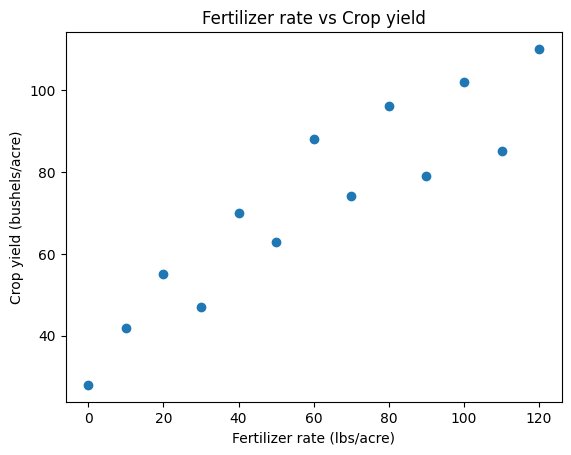

In [ ]:
# 1) Visualize the data (run this cell)
plt.figure()
plt.scatter(data["fertilizer_rate"], data["crop_yield"])
plt.xlabel("Fertilizer rate (lbs/acre)")
plt.ylabel("Crop yield (bushels/acre)")
plt.title("Fertilizer rate vs Crop yield")
plt.show()

In [ ]:
# 2) Train/test split (run this cell)
X = data[["fertilizer_rate"]].values
y = data["crop_yield"].values

# Fixed split so everyone gets the same result
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train points:", len(X_train))
print("Test points:", len(X_test))

Train points: 9
Test points: 4


<p>One-sentence intuition on the degrees</p>

<p>Degree = how flexible the model is.<br>
Low degree = too stiff.<br>
High degree = too wiggly.<br>
The goal is just right.</p><p>

How it relates to Bias and Variance:</p><p>
Degree 1, Bias is High, Variance is Low, Typical Behavior is Model Underfitting (this is fitting a straight line to the data).</p><p>
Degree 2-3, Bias is Medium, Variance is Medium, Typical Behavior is Good (this is fitting a generalized line to the data).</p><p>
Degree 5-9, Bias is Low, Variance is High, Typical Behavior is Overfitting (this performs great on the training data and poorly on the testing or new data).</p><p>
We will be calculated MSE and R Squared, but not P value for these examples because P values measure confidence in coefficients, not prediction quality and we are interested in prediction quality for this exercise.</p>


### First Model: degree = 1, straight line simple linear regression

In [ ]:
# Degree 1 = straight line
# This model is simple (straight line) but it cannot capture the curve!
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_train_pred_1 = lin_reg.predict(X_train)
y_test_pred_1 = lin_reg.predict(X_test)

print("Linear model")
print("Train MSE:", mean_squared_error(y_train, y_train_pred_1))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_1))

Linear model
Train MSE: 48.24825662482567
Test MSE: 207.16088653910137


In [ ]:
#Linear Model degree = 1 (straight line)
# Training R²
r2_train_lin = r2_score(y_train, y_train_pred_1)

# Test R²
r2_test_lin = r2_score(y_test, y_test_pred_1)

print("Linear model R²")
print("Train R²:", r2_train_lin)
print("Test R²:", r2_test_lin)


Linear model R²
Train R²: 0.9035463550369989
Test R²: 0.6964675655104742


### Second model, we will create new features to allow the linear regression to model the curve, linear regression doesn’t know how to curve unless we give it curved features

In [ ]:
# Create polynomial features (this is what allows the curve)
poly = PolynomialFeatures(degree=8, include_bias=False)

# Create the train and test sets
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# Fit linear regression on the polynomial features
model_deg8 = LinearRegression()
model_deg8.fit(X_train_poly, y_train)

# Predictions
y_train_pred = model_deg8.predict(X_train_poly)
y_test_pred  = model_deg8.predict(X_test_poly)

# Errors
print("Degree 8 model")
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Degree 8 model
Train MSE: 31.893580885651716
Test MSE: 9993.460187201243


In [ ]:
#R squared for the degree 8 model
#note: A negative R squared means the model is worse than predicting the average every time.
r2_train_deg8 = r2_score(y_train, y_train_pred)
r2_test_deg8  = r2_score(y_test, y_test_pred)

print("Degree 8 model R²")
print("Train R²:", r2_train_deg8)
print("Test R²:", r2_test_deg8)

Degree 8 model R²
Train R²: 0.936241175484037
Test R²: -13.64243250871977


## Reflection questions (double click on the markdown cell and add your answers in markdown)

Answer in **1–3 sentences each**:

1. Which model has the **highest bias**? What did you observe that supports that? **The degree 1 model has the highest bias because it is too simple to capture the curved pattern in the data**
2. Which model has the **highest variance**? What did you observe that supports that? **The degree 8 model has the highest variance because it fits the training data well but performs terribly on the test data. This is shown by the huge jump from Train MSE ≈ 31.89 to Test MSE ≈ 9993.46**
3. Which model seems **best for predicting new farms** (generalization)? Why?
**The degree 1 model is better for predicting new farms between these two models because its test performance is much better than the degree 8 model**
4. Explain **overfitting** using your plot *and* the train/test MSE table.
**Overfitting happens when a model becomes too complex and starts learning random noise instead of the real pattern. The degree 8 model overfits because it has a low training error but an extremely high test error**
5. Optional: What fertilizer rate looks “near-optimal” from the scatter plot?
**The fertilizer rate that looks near-optimal is around 100–120 lbs/acre**
6. Which model has the higher R squared on the training data, and why does that not mean it is the better model? **The degree 8 model has the higher training R² because it is more flexible and fits the training data more closely.**